In [1]:
import pandas as pd

# Official NSL-KDD column names
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]

df = pd.read_csv('../data/KDDTrain+.txt', names=columns)
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [2]:
# Basic shape and info
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nLabel distribution:\n", df['label'].value_counts())

Shape: (125973, 43)

Column names: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty']

Label distribution:
 label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back      

In [3]:
# Map specific attack names into 4 standard attack categories
attack_map = {
    'normal': 'normal',
    # DoS attacks
    'neptune': 'DoS', 'smurf': 'DoS', 'back': 'DoS', 'teardrop': 'DoS',
    'pod': 'DoS', 'land': 'DoS', 'apache2': 'DoS', 'udpstorm': 'DoS',
    'processtable': 'DoS', 'worm': 'DoS', 'mailbomb': 'DoS',
    # Probe attacks
    'satan': 'Probe', 'ipsweep': 'Probe', 'portsweep': 'Probe',
    'nmap': 'Probe', 'mscan': 'Probe', 'saint': 'Probe',
    # R2L attacks
    'guess_passwd': 'R2L', 'ftp_write': 'R2L', 'imap': 'R2L',
    'phf': 'R2L', 'multihop': 'R2L', 'warezmaster': 'R2L',
    'warezclient': 'R2L', 'spy': 'R2L', 'xlock': 'R2L', 'xsnoop': 'R2L',
    'snmpguess': 'R2L', 'snmpgetattack': 'R2L', 'httptunnel': 'R2L',
    'sendmail': 'R2L', 'named': 'R2L',
    # U2R attacks
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'rootkit': 'U2R',
    'perl': 'U2R', 'sqlattack': 'U2R', 'xterm': 'U2R', 'ps': 'U2R'
}

df['attack_category'] = df['label'].map(attack_map)

# Check for anything we missed
print("Unmapped labels:", df[df['attack_category'].isna()]['label'].unique())

print("\nAttack category distribution:\n", df['attack_category'].value_counts())

Unmapped labels: <StringArray>
[]
Length: 0, dtype: str

Attack category distribution:
 attack_category
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


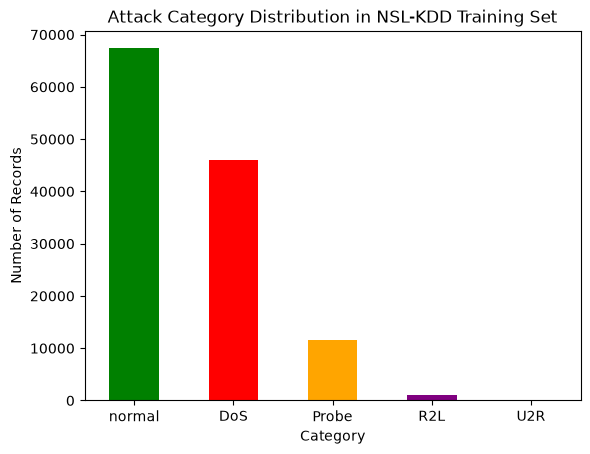

In [4]:
import matplotlib.pyplot as plt

# Visualize attack category distribution
df['attack_category'].value_counts().plot(kind='bar', color=['green','red','orange','purple','blue'])
plt.title('Attack Category Distribution in NSL-KDD Training Set')
plt.xlabel('Category')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.show()

In [5]:
from sklearn.preprocessing import LabelEncoder

# Columns that contain text instead of numbers
categorical_cols = ['protocol_type', 'service', 'flag']

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le  # save it, we'll need it later for the test set

print("Encoding done. Sample of cleaned data:")
df[categorical_cols].head()

Encoding done. Sample of cleaned data:


,protocol_type,service,flag
0,1,20,9
1,2,44,9
2,1,49,5
3,1,24,9
4,1,24,9


In [6]:
# Drop columns we don't need for training the model
# 'label' = original text label (already captured in attack_category)
# 'difficulty' = a scoring metadata field, not a real network feature
# 'num_outbound_cmds' = known to always be 0 in this dataset (adds no value)

X = df.drop(columns=['label', 'difficulty', 'attack_category', 'num_outbound_cmds'])
y = df['attack_category']  # our target labels, kept separately

print("Features (X) shape:", X.shape)
print("Labels (y) shape:", y.shape)
print("\nAll columns are numeric?", X.select_dtypes(include='object').empty)
X.head()

Features (X) shape: (125973, 40)
Labels (y) shape: (125973,)

All columns are numeric? True


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,1,20,9,491,0,0,0,0,0,...,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00
1,0,2,44,9,146,0,0,0,0,0,...,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00
2,0,1,49,5,0,0,0,0,0,0,...,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00
3,0,1,24,9,232,8153,0,0,0,0,...,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01
4,0,1,24,9,199,420,0,0,0,0,...,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [7]:
from sklearn.model_selection import train_test_split

# Separate normal traffic from attack traffic
X_normal = X[y == 'normal']
X_attack = X[y != 'normal']
y_attack = y[y != 'normal']

print("Normal traffic samples:", X_normal.shape[0])
print("Attack traffic samples:", X_attack.shape[0])

# Split normal data: most for training, some held back for testing
X_train, X_test_normal = train_test_split(X_normal, test_size=0.2, random_state=42)

print("\nTraining set (normal only):", X_train.shape[0])
print("Test set (normal, held back):", X_test_normal.shape[0])

Normal traffic samples: 67343
Attack traffic samples: 58630

Training set (normal only): 53874
Test set (normal, held back): 13469


In [8]:
from sklearn.ensemble import IsolationForest

# Create and train the model on ONLY normal traffic
model = IsolationForest(
    n_estimators=100,      # number of decision trees to build
    contamination=0.1,     # our estimate of what % of real traffic might be anomalous
    random_state=42,
    n_jobs=-1               # use all CPU cores to train faster
)

model.fit(X_train)

print("Model trained successfully.")
print("Number of trees:", model.n_estimators)

Model trained successfully.
Number of trees: 100


In [9]:
import numpy as np

# Combine held-back normal data + all attack data into one test set
X_test_combined = pd.concat([X_test_normal, X_attack])
y_test_combined = ['normal'] * len(X_test_normal) + ['attack'] * len(X_attack)

# Ask the model to predict: -1 = anomaly (flagged), 1 = normal
predictions = model.predict(X_test_combined)

# Convert model's -1/1 output into readable labels
predicted_labels = ['attack' if p == -1 else 'normal' for p in predictions]

# Compare predictions to reality
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test_combined, predicted_labels, labels=['normal','attack']))

print("\nClassification Report:")
print(classification_report(y_test_combined, predicted_labels, labels=['normal','attack']))


Confusion Matrix:
[[12071  1398]
 [ 4314 54316]]

Classification Report:
              precision    recall  f1-score   support

      normal       0.74      0.90      0.81     13469
      attack       0.97      0.93      0.95     58630

    accuracy                           0.92     72099
   macro avg       0.86      0.91      0.88     72099
weighted avg       0.93      0.92      0.92     72099



In [10]:
# Simple rule-based baseline detector
# Flags a connection as "attack" if it shows classic suspicious signals

def rule_based_predict(row):
    if row['num_failed_logins'] > 3:
        return 'attack'
    if row['serror_rate'] > 0.5:
        return 'attack'
    if row['num_compromised'] > 0:
        return 'attack'
    return 'normal'

# Apply the rule to our same combined test set
rule_predictions = X_test_combined.apply(rule_based_predict, axis=1)

print("Rule-Based Confusion Matrix:")
print(confusion_matrix(y_test_combined, rule_predictions, labels=['normal','attack']))

print("\nRule-Based Classification Report:")
print(classification_report(y_test_combined, rule_predictions, labels=['normal','attack']))

Rule-Based Confusion Matrix:
[[13324   145]
 [22884 35746]]

Rule-Based Classification Report:
              precision    recall  f1-score   support

      normal       0.37      0.99      0.54     13469
      attack       1.00      0.61      0.76     58630

    accuracy                           0.68     72099
   macro avg       0.68      0.80      0.65     72099
weighted avg       0.88      0.68      0.72     72099



In [11]:
from sklearn.neighbors import LocalOutlierFactor

# LOF works differently from Isolation Forest — it must be trained AND tested in one step (novelty=True lets us split that)
lof_model = LocalOutlierFactor(
    n_neighbors=20,        # how many nearby points to compare each point against
    contamination=0.1,     # same assumption as before: ~10% of test traffic may be anomalous
    novelty=True           # allows us to fit on training data, then predict separately on test data
)

lof_model.fit(X_train)

lof_predictions = lof_model.predict(X_test_combined)
lof_predicted_labels = ['attack' if p == -1 else 'normal' for p in lof_predictions]

print("Local Outlier Factor — Confusion Matrix:")
print(confusion_matrix(y_test_combined, lof_predicted_labels, labels=['normal','attack']))

print("\nLocal Outlier Factor — Classification Report:")
print(classification_report(y_test_combined, lof_predicted_labels, labels=['normal','attack']))

c:\Users\LOQ\OneDrive\Desktop\ai-soc-agent\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


Local Outlier Factor — Confusion Matrix:
[[12062  1407]
 [ 3803 54827]]

Local Outlier Factor — Classification Report:
              precision    recall  f1-score   support

      normal       0.76      0.90      0.82     13469
      attack       0.97      0.94      0.95     58630

    accuracy                           0.93     72099
   macro avg       0.87      0.92      0.89     72099
weighted avg       0.93      0.93      0.93     72099



In [12]:
import joblib
import os

# Create a folder to store trained models
os.makedirs('../backend/models', exist_ok=True)

# Save the trained Isolation Forest model
joblib.dump(model, '../backend/models/isolation_forest.pkl')

# Save the label encoders too — we'll need them to convert new text data the same way
joblib.dump(encoders, '../backend/models/encoders.pkl')

# Save the exact column order the model expects
joblib.dump(list(X_train.columns), '../backend/models/feature_columns.pkl')

print("Model, encoders, and feature columns saved successfully.")

Model, encoders, and feature columns saved successfully.


In [13]:
# Save the average value of each feature from real training data
# These will be used as sensible defaults for features our simulator doesn't provide
feature_means = X_train.mean().to_dict()

joblib.dump(feature_means, '../backend/models/feature_means.pkl')
print("Feature means saved successfully.")
print("\nSample means:", {k: round(v, 2) for k, v in list(feature_means.items())[:5]})

Feature means saved successfully.

Sample means: {'duration': 163.67, 'protocol_type': 1.17, 'service': 27.02, 'flag': 8.6, 'src_bytes': 13110.6}


In [14]:
# Train a second, lightweight Isolation Forest using ONLY the features our live simulator provides
live_features = ['protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'num_failed_logins', 'serror_rate']

X_train_live = X_train[live_features]

live_model = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=42,
    n_jobs=-1
)
live_model.fit(X_train_live)

joblib.dump(live_model, '../backend/models/isolation_forest_live.pkl')
joblib.dump(live_features, '../backend/models/live_feature_columns.pkl')

print("Live-compatible model trained and saved.")

Live-compatible model trained and saved.


In [15]:
# Export a sample of REAL normal traffic (original text values) for the simulator to draw from
live_features = ['protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'num_failed_logins', 'serror_rate']

normal_sample = X_train[live_features].copy()
normal_sample['protocol_type'] = encoders['protocol_type'].inverse_transform(normal_sample['protocol_type'])
normal_sample['service'] = encoders['service'].inverse_transform(normal_sample['service'])
normal_sample['flag'] = encoders['flag'].inverse_transform(normal_sample['flag'])

normal_sample.to_csv('../backend/models/normal_traffic_sample.csv', index=False)
print("Saved", len(normal_sample), "real normal traffic samples for the simulator.")
normal_sample.head()

Saved 53874 real normal traffic samples for the simulator.


,protocol_type,service,flag,src_bytes,dst_bytes,num_failed_logins,serror_rate
68808,tcp,http,SF,243,1229,0,0.0
39094,tcp,http,SF,241,1380,0,0.0
95435,tcp,http,SF,238,1378,0,0.0
45185,tcp,http,SF,345,3874,0,0.0
44907,tcp,http,SF,332,1287,0,0.0
